In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fire_path = "fire_archive_M-C61_731469.csv"
fires = pd.read_csv(fire_path)
fires.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,38.8211,-106.5140,311.5,1.6,1.2,2018-01-06,1825,Terra,MODIS,0,6.03,265.9,32.4,D,0
1,37.4673,-105.8486,303.4,1.1,1.0,2018-01-12,1749,Terra,MODIS,56,6.03,278.6,8.3,D,2
2,37.6919,-103.4498,322.8,1.0,1.0,2018-01-12,1749,Terra,MODIS,82,6.03,278.7,24.5,D,0
3,37.6903,-103.4387,305.1,1.0,1.0,2018-01-12,1749,Terra,MODIS,61,6.03,276.8,10.5,D,0
4,37.6896,-103.4591,317.0,2.7,1.6,2018-01-16,2041,Aqua,MODIS,77,6.03,272.2,81.5,D,0


In [3]:
print("Date range:", fires["acq_date"].min(), "to", fires["acq_date"].max())
print(fires[["latitude","longitude"]].describe())

Date range: 2018-01-06 to 2024-03-31
           latitude     longitude
count  12211.000000  12211.000000
mean      39.442867   -106.605509
std        1.182213      1.486134
min       37.000900   -109.060000
25%       38.489000   -107.925850
50%       39.698400   -106.305100
75%       40.522150   -105.711150
max       41.000000   -102.040700


In [4]:
fires["confidence"] = pd.to_numeric(fires["confidence"], errors="coerce")
fires_hi = fires[fires["confidence"] >= 30].copy()  # you can tune threshold later
print("High-confidence fires:", len(fires_hi))

High-confidence fires: 11453


In [1]:
import xarray as xr

ds_tmmx = xr.open_dataset("tmmx_2018.nc")
ds_tmmx

<xarray.Dataset>
Dimensions:          (lon: 1386, lat: 585, day: 365, crs: 1)
Coordinates:
  * lon              (lon) float64 -124.8 -124.7 -124.7 ... -67.14 -67.1 -67.06
  * lat              (lat) float64 49.4 49.36 49.32 49.28 ... 25.15 25.11 25.07
  * day              (day) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * crs              (crs) uint16 3
Data variables:
    air_temperature  (day, lat, lon) float32 ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       25 April 2021
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [2]:

print(ds_tmmx.data_vars)
print(ds_tmmx.dims)


Data variables:
    air_temperature  (day, lat, lon) float32 ...
Frozen({'lon': 1386, 'lat': 585, 'day': 365, 'crs': 1})


In [5]:
ds_tmmx

<xarray.Dataset>
Dimensions:          (lon: 1386, lat: 585, day: 365, crs: 1)
Coordinates:
  * lon              (lon) float64 -124.8 -124.7 -124.7 ... -67.14 -67.1 -67.06
  * lat              (lat) float64 49.4 49.36 49.32 49.28 ... 25.15 25.11 25.07
  * day              (day) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * crs              (crs) uint16 3
Data variables:
    air_temperature  (day, lat, lon) float32 ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       25 April 2021
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [11]:

lon_min, lon_max = -109.06, -102.04
lat_min, lat_max =  37.00,  41.00

co_tmmx_2018 = ds_tmmx.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)
)

co_tmmx_2018


<xarray.Dataset>
Dimensions:          (lon: 169, lat: 96, day: 365, crs: 1)
Coordinates:
  * lon              (lon) float64 -109.1 -109.0 -109.0 ... -102.1 -102.1 -102.1
  * lat              (lat) float64 40.98 40.94 40.9 40.86 ... 37.11 37.07 37.03
  * day              (day) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * crs              (crs) uint16 3
Data variables:
    air_temperature  (day, lat, lon) float32 ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       25 April 2021
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [12]:
co_tmmx_2018["air_temperature_c"] = (
    co_tmmx_2018["air_temperature"] - 273.15
)

co_tmmx_2018["air_temperature_c"]


<xarray.DataArray 'air_temperature_c' (day: 365, lat: 96, lon: 169)>
array([[[  1.4500122 ,   2.0500183 ,   1.0500183 , ...,  -9.649994  ,
          -9.75      , -10.049988  ],
        [ -0.25      ,   0.5500183 ,   2.0500183 , ...,  -9.449982  ,
          -9.549988  ,  -9.75      ],
        [  3.75      ,   1.5500183 ,   1.1499939 , ...,  -8.75      ,
          -9.149994  ,  -9.350006  ],
        ...,
        [ 11.550018  ,  11.350006  ,  11.649994  , ...,  -5.4499817 ,
          -5.4499817 ,  -5.649994  ],
        [ 11.950012  ,  11.550018  ,  11.649994  , ...,  -5.149994  ,
          -5.549988  ,  -5.549988  ],
        [ 11.550018  ,  11.649994  ,  11.350006  , ...,  -5.350006  ,
          -5.4499817 ,  -5.549988  ]],

       [[  0.8500061 ,   1.3500061 ,   0.75      , ...,  -2.149994  ,
          -2.350006  ,  -2.4499817 ],
        [ -0.1499939 ,   0.05001831,   1.25      , ...,  -1.75      ,
          -1.6499939 ,  -1.8500061 ],
        [  3.4500122 ,   1.3500061 ,   1.0500183 , ...,  -0.75      ,
          -0.9499817 ,  -1.25      ],
...
        [ -4.25      ,  -4.350006  ,  -4.049988  , ...,   3.9500122 ,
           3.350006  ,   3.149994  ],
        [ -3.4499817 ,  -3.9499817 ,  -4.149994  , ...,   3.649994  ,
           3.0500183 ,   2.9500122 ],
        [ -3.25      ,  -3.850006  ,  -4.25      , ...,   3.649994  ,
           2.850006  ,   2.75      ]],

       [[ -1.8500061 ,  -1.5499878 ,  -1.5499878 , ...,   4.649994  ,
           4.5500183 ,   4.450012  ],
        [ -2.75      ,  -2.25      ,  -1.75      , ...,   4.649994  ,
           4.649994  ,   4.649994  ],
        [  1.0500183 ,  -0.6499939 ,  -1.0499878 , ...,   4.75      ,
           4.75      ,   4.75      ],
        ...,
        [  5.350006  ,   5.149994  ,   5.149994  , ...,   9.550018  ,
           9.550018  ,   9.550018  ],
        [  5.25      ,   5.149994  ,   5.350006  , ...,   9.649994  ,
           9.649994  ,   9.649994  ],
        [  5.649994  ,   5.450012  ,   5.450012  , ...,   9.75      ,
           9.649994  ,   9.649994  ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 -109.1 -109.0 -109.0 -108.9 ... -102.1 -102.1 -102.1
  * lat      (lat) float64 40.98 40.94 40.9 40.86 ... 37.15 37.11 37.07 37.03
  * day      (day) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31

In [13]:
print(co_tmmx_2018.dims)

Frozen({'lon': 169, 'lat': 96, 'day': 365, 'crs': 1})


In [9]:

co_tmmx_2018.to_netcdf("tmmx_2018_CO.nc")
print("Saved tmmx_2018_CO.nc")


Saved tmmx_2018_CO.nc


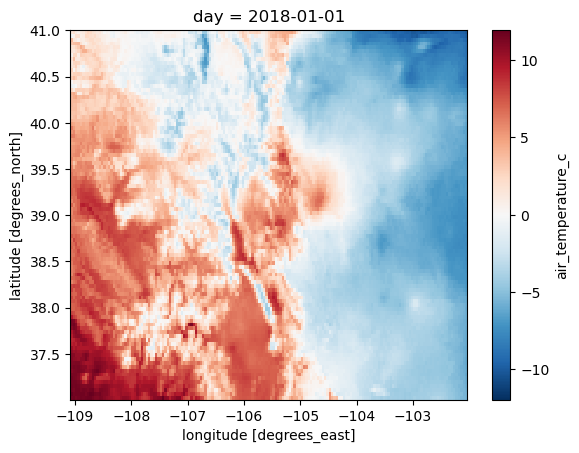

In [14]:
co_tmmx_2018["air_temperature_c"].isel(day=0).plot()

In [15]:

co_tmmx_2018.to_netcdf("tmmx_2018_CO.nc")
print("Saved corrected Colorado subset")


Saved corrected Colorado subset
